In [9]:
import torch
import pprint
import numpy as np

from tqdm import tqdm
from src.util.celano_lab_scripts import process_image
from src.datasets.mos2_sef import MOS2SEFDataset, Formulation
from src.models.our_method.swin_cafm import SwinCAFM
from src.models.our_method.older_surrogate import MultiHeadOlderSurrogate

# p(y_char | y_hat)
surrogate_weights = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/e. surrogate standalone train-runs/2025-02-12_10-49-50_older_surrogate_mh-VGG-l[-2]+layernorm-adamW-lr=1e-4-augs=True-iii/older_surrogate_mh-VGG-l[-2]+layernorm-adamW-lr=1e-4-augs=True-iii_best_older_surrogate.pth"
surrogate = torch.load(surrogate_weights).cuda().float()

# p(y | y_sparse)
model_weights = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/a. train-runs/2025-02-13_13-43-04_SwinIR-loss=OLDER-W-Perceptual-VGG-aug=F-Multi-Layer+L1(raw-out, y)-lambda=1e-3/SwinIR-loss=OLDER-W-Perceptual-VGG-aug=F-Multi-Layer+L1(raw-out, y)-lambda=1e-3_best.pth"
model = torch.load(model_weights).cuda().float()

model.train()
surrogate.eval()

formulation = Formulation.P_Y_BAR_Y_SPARSE
train_dataset = MOS2SEFDataset("train", formulation, 128, 1, 2000)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
val_dataset = MOS2SEFDataset("val", formulation, 128, 1, 2000)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

optimizer = torch.optim.Adam(model.parameters())

IMG_SIZE_UM=2.0
values = {}

Xs = []; ys = []

@torch.no_grad()
def sample():
    
    for i, data in tqdm(enumerate(train_dataloader), total=len(train_dataloader)):
        
        y = data['y'].cuda().float()
        mask = data['mask'].cuda().float()
        y_sparse = (mask * y).cuda().float()
        y_hat = model(y_sparse).cuda().float()
        
        # older_pred = surrogate(y/y_hat)
        # char_gt = surrogate(y); char_pred = surrogate(y_hat)
        
        y_char = process_image(y, 2.0)
        y_hat_char = process_image(y_hat, 2.0)
        y_char_arr = []
        y_hat_char_arr = []
        
        for k, v in y_char.items():
            y_char_arr.append(v)
        
        for k, v in y_hat_char.items():
            y_hat_char_arr.append(v)
            
        y_char_arr = np.array(y_char_arr)
        y_hat_char_arr = np.array(y_hat_char_arr)
        
        # pred - og
        diffs = y_hat_char_arr - y_char_arr

        l1 = torch.nn.functional.l1_loss(y, y_hat)
        
        X_arr = diffs
        y_arr = l1.detach().cpu().numpy()
        
        Xs.append(X_arr)
        ys.append(y_arr)
                      
sample()

/tmp/ipykernel_3330516/709634501.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  surrogate = torch.load(surrogate_weights).cuda().float()
/tmp/ipykernel_3330516/7096345

# Sanity Check: OLDER-Script Robustness
---

In [48]:
import torch.nn.functional as F
def scale_image(image, scale):
    """
    Scales the input image by `scale` (using bilinear interpolation)
    and then crops a central patch of the original size.
    
    Args:
        image (torch.Tensor): A 2D tensor of shape (H, W).
        scale (float): Scaling factor.
        
    Returns:
        torch.Tensor: Processed image of shape (H, W).
    """
    # Original dimensions
    H, W = image.shape
    # New dimensions after scaling
    new_H, new_W = int(H * scale), int(W * scale)
    
    # Scale the image: add batch and channel dims for interpolation.
    image_scaled = F.interpolate(image.unsqueeze(0).unsqueeze(0).float(),
                                 size=(new_H, new_W),
                                 mode='bilinear',
                                 align_corners=False)
    # Remove batch and channel dims
    image_scaled = image_scaled.squeeze(0).squeeze(0)
    
    # Crop the central region of size (H, W)
    start_H = (new_H - H) // 2
    start_W = (new_W - W) // 2
    cropped_image = image_scaled[start_H:start_H+H, start_W:start_W+W]
    
    return cropped_image

In [60]:
ex_image = train_dataloader.dataset[0]['y']

rotated_img = torch.rot90(ex_image, k=1, dims=(0, 1))
scaled_img_up = scale_image((rotated_img), 1.01)
scaled_img_up_ii = scale_image((rotated_img), 1.02)
scaled_img_up_iii = scale_image((rotated_img), 1.03)

print("---- original ----")
pprint.pprint(process_image(ex_image, 2.0))
print("---- rotated ----")
pprint.pprint(process_image(rotated_img, 2.0))
print("---- scaled up----")
pprint.pprint(process_image(scaled_img_up, 2.0))
print("---- scaled up-ii ----")
pprint.pprint(process_image(scaled_img_up_ii, 2.0))
print("---- scaled up-iii ----")
pprint.pprint(process_image(scaled_img_up_iii, 2.0))

---- original ----
{'average_surface_current': 467450469.73228455,
 'coverage_percentage': 42.181396484375,
 'num_circular_shapes': 85,
 'num_curved_lines': 1,
 'num_extended_shapes': 1,
 'total_area_circular_shapes': 0.9071044921875,
 'total_area_extended_shapes': 0.120361328125,
 'total_defect_area': 0.006271153688430786,
 'total_len_detected_curves': 12.356266835704446}
---- rotated ----
{'average_surface_current': 467450499.53460693,
 'coverage_percentage': 42.181396484375,
 'num_circular_shapes': 85,
 'num_curved_lines': 2,
 'num_extended_shapes': 0,
 'total_area_circular_shapes': 0.9071044921875,
 'total_area_extended_shapes': 0.0,
 'total_defect_area': 0.005536526441574097,
 'total_len_detected_curves': 15.673589585348964}
---- scaled up----
{'average_surface_current': 467894256.1149597,
 'coverage_percentage': 58.477783203125,
 'num_circular_shapes': 80,
 'num_curved_lines': 2,
 'num_extended_shapes': 0,
 'total_area_circular_shapes': 0.91064453125,
 'total_area_extended_shapes

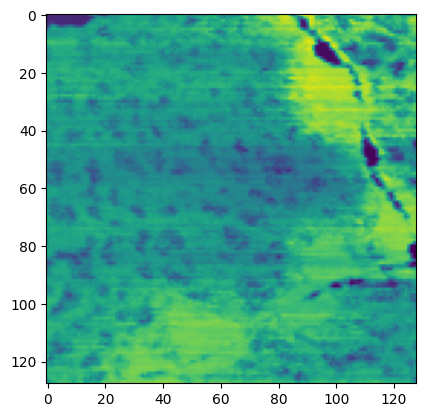

In [59]:
import matplotlib.pyplot as plt
plt.imshow(ex_image);

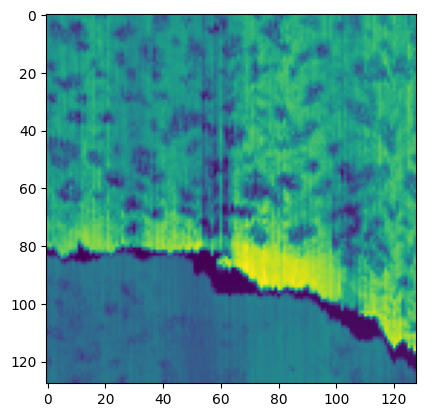

In [56]:
plt.imshow(rotated_img);

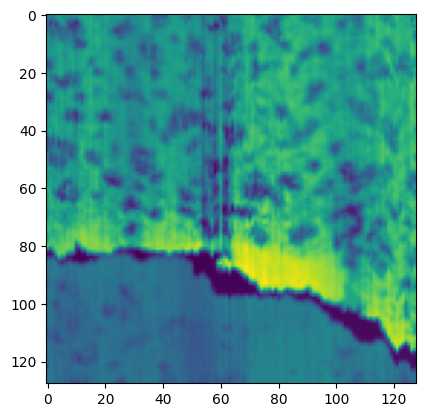

In [57]:
plt.imshow(scaled_img_down);

# [Training Set] OLDER-L1 Feature Correlation
---

In [10]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.utils import resample  # for creating bootstrap samples

# -------------------------------------------------------
# 1. Pretend these are your collected surrogate features & L1 losses
#    Xs.shape => (N, 9)
#    ys.shape => (N,)
# -------------------------------------------------------
# For illustration, let's assume you already have Xs and ys.
Xs = np.array(Xs).squeeze()
ys = np.array(ys).squeeze()

X = Xs
y = ys

# Define number of bootstrap iterations
n_iterations = 50

# This list will store the results for each feature
results = []

# -------------------------------------------------------
# 2. Loop over each of the 9 input features
# -------------------------------------------------------
n_features = X.shape[1]
for feature_idx in range(n_features):
    print(f"\nEvaluating Feature {feature_idx + 1} in isolation...")
    
    # Use only one feature (keep shape as (N, 1))
    X_single = X[:, feature_idx].reshape(-1, 1)
    
    # Split into train/test sets using only the selected feature
    X_train, X_test, y_train, y_test = train_test_split(
        X_single, y, test_size=0.2, random_state=42
    )
    
    all_mae = []
    
    # -------------------------------------------------------
    # 3. Apply Bootstrapping for the current feature
    # -------------------------------------------------------
    for i in range(n_iterations):
        # Create a bootstrap sample from the training set
        X_train_bs, y_train_bs = resample(X_train, y_train, random_state=40 + i)
        
        # Train the Random Forest Regressor on this bootstrap sample
        rf_model = RandomForestRegressor(
            n_estimators=100,
            random_state=40 + i,
        )
        rf_model.fit(X_train_bs, y_train_bs)
        
        # Evaluate performance on the test set
        y_pred = rf_model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        all_mae.append(mae)
    
    # Compute the average and standard deviation of the MAE for this feature
    mean_mae = np.mean(all_mae)
    std_mae = np.std(all_mae)
    
    results.append((feature_idx + 1, mean_mae, std_mae))
    print(f"  Bootstrapped Mean Test MAE: {mean_mae:.4f} ± {std_mae:.4f}")

# -------------------------------------------------------
# 4. Print a summary comparing all features
# -------------------------------------------------------
print("\nSummary of MAE for each feature (lower is better):")
for feature, mean_mae, std_mae in results:
    print(f"  Feature {feature}: MAE = {mean_mae:.4f} ± {std_mae:.4f}")


Evaluating Feature 1 in isolation...
  Bootstrapped Mean Test MAE: 0.0027 ± 0.0001

Evaluating Feature 2 in isolation...
  Bootstrapped Mean Test MAE: 0.0028 ± 0.0001

Evaluating Feature 3 in isolation...
  Bootstrapped Mean Test MAE: 0.0026 ± 0.0001

Evaluating Feature 4 in isolation...
  Bootstrapped Mean Test MAE: 0.0021 ± 0.0000

Evaluating Feature 5 in isolation...
  Bootstrapped Mean Test MAE: 0.0027 ± 0.0001

Evaluating Feature 6 in isolation...
  Bootstrapped Mean Test MAE: 0.0022 ± 0.0000

Evaluating Feature 7 in isolation...
  Bootstrapped Mean Test MAE: 0.0021 ± 0.0000

Evaluating Feature 8 in isolation...
  Bootstrapped Mean Test MAE: 0.0021 ± 0.0000

Evaluating Feature 9 in isolation...
  Bootstrapped Mean Test MAE: 0.0027 ± 0.0001

Summary of MAE for each feature (lower is better):
  Feature 1: MAE = 0.0027 ± 0.0001
  Feature 2: MAE = 0.0028 ± 0.0001
  Feature 3: MAE = 0.0026 ± 0.0001
  Feature 4: MAE = 0.0021 ± 0.0000
  Feature 5: MAE = 0.0027 ± 0.0001
  Feature 6: MAE 

In [11]:
print("\nSummary of MAE for each feature (lower is better):")
for feature, mean_mae, std_mae in results:
    print(f"  Feature {feature}: MAE = {mean_mae:.10f} ± {std_mae:.10f}")


Summary of MAE for each feature (lower is better):
  Feature 1: MAE = 0.0027384153 ± 0.0000639075
  Feature 2: MAE = 0.0027562218 ± 0.0000636159
  Feature 3: MAE = 0.0025741332 ± 0.0000607777
  Feature 4: MAE = 0.0021473568 ± 0.0000403291
  Feature 5: MAE = 0.0027048338 ± 0.0000577084
  Feature 6: MAE = 0.0021849454 ± 0.0000180440
  Feature 7: MAE = 0.0021416380 ± 0.0000078667
  Feature 8: MAE = 0.0021007970 ± 0.0000067318
  Feature 9: MAE = 0.0027275957 ± 0.0000644674


# [Validation Set] OLDER-L1 Feature Correlation
---

In [6]:
Xs = []; ys = []
@torch.no_grad()

def sample():
    for i, data in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
        y = data['y'].cuda().float()
        mask = data['mask'].cuda().float()
        y_sparse = (mask * y).cuda().float()
        y_hat = model(y_sparse).cuda().float()
        # older_pred = surrogate(y/y_hat)
        # char_gt = surrogate(y); char_pred = surrogate(y_hat)
        y_char = process_image(y, 2.0)
        y_hat_char = process_image(y_hat, 2.0)
        y_char_arr = []
        y_hat_char_arr = []
        for k, v in y_char.items():
            y_char_arr.append(v)
        for k, v in y_hat_char.items():
            y_hat_char_arr.append(v)
        y_char_arr = np.array(y_char_arr)
        y_hat_char_arr = np.array(y_hat_char_arr)
        # pred - og
        diffs = y_hat_char_arr - y_char_arr
        l1 = torch.nn.functional.l1_loss(y, y_hat)
        X_arr = diffs
        y_arr = l1.detach().cpu().numpy()
        Xs.append(X_arr)
        ys.append(y_arr)
                      
sample()

100%|██████████| 2000/2000 [02:47<00:00, 11.96it/s]


In [14]:
import numpy as np
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.utils import resample  # for creating bootstrap samples

# -----------------------------------------------------------------
# 1. Assume Xs and ys contain your data with shape (N, 9) and (N,)
# -----------------------------------------------------------------
Xs = np.array(Xs).squeeze()  # e.g. shape (N, 9)
ys = np.array(ys).squeeze()  # e.g. shape (N,)

X = Xs
y = ys

n_iterations = 1
n_features = X.shape[1]

# Storage for results on every subset
# Each entry in 'all_results' will be a tuple: (subset_of_features, mean_MAE, std_MAE)
all_results = []

# Track the best subset found
best_subset = None
best_mean_mae = float('inf')
best_std_mae = None

# --------------------------------------------------------
# 2. Enumerate ALL subsets of features: from size 1 to 9
# --------------------------------------------------------
for subset_size in range(1, n_features + 1):
    for subset_indices in combinations(range(n_features), subset_size):
        # Extract only the columns in this subset
        X_subset = X[:, subset_indices]

        # Split dataset
        X_train, X_test, y_train, y_test = train_test_split(
            X_subset, y, test_size=0.2, random_state=42
        )

        # Bootstrapping loop
        maes = []
        for i in range(n_iterations):
            X_train_bs, y_train_bs = resample(X_train, y_train, random_state=40 + i)
            
            rf_model = RandomForestRegressor(
                n_estimators=100,
                random_state=40 + i
            )
            rf_model.fit(X_train_bs, y_train_bs)

            y_pred = rf_model.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)
            maes.append(mae)

        mean_mae = np.mean(maes)
        std_mae = np.std(maes)

        # Store results
        all_results.append((subset_indices, mean_mae, std_mae))

        # Check if this is the best subset so far
        if mean_mae < best_mean_mae:
            best_mean_mae = mean_mae
            best_subset = subset_indices
            best_std_mae = std_mae

# --------------------------------------------------------
# 3. Print the best subset and a brief summary of all
# --------------------------------------------------------
print("Optimal Feature Subset Search Results:")
print("--------------------------------------")
print(f"Best Subset of Features: {best_subset}")
print(f"  Mean MAE = {best_mean_mae:.6f} ± {best_std_mae:.6f}\n")

print("All Subset Results (lower MAE is better):")
for subset_indices, mean_mae, std_mae in all_results:
    print(f" Subset {subset_indices} -> MAE = {mean_mae:.6f} ± {std_mae:.6f}")


Optimal Feature Subset Search Results:
--------------------------------------
Best Subset of Features: (3, 6, 7)
  Mean MAE = 0.002001 ± 0.000000

All Subset Results (lower MAE is better):
 Subset (0,) -> MAE = 0.002855 ± 0.000000
 Subset (1,) -> MAE = 0.002777 ± 0.000000
 Subset (2,) -> MAE = 0.002586 ± 0.000000
 Subset (3,) -> MAE = 0.002075 ± 0.000000
 Subset (4,) -> MAE = 0.002734 ± 0.000000
 Subset (5,) -> MAE = 0.002198 ± 0.000000
 Subset (6,) -> MAE = 0.002145 ± 0.000000
 Subset (7,) -> MAE = 0.002105 ± 0.000000
 Subset (8,) -> MAE = 0.002846 ± 0.000000
 Subset (0, 1) -> MAE = 0.002403 ± 0.000000
 Subset (0, 2) -> MAE = 0.002373 ± 0.000000
 Subset (0, 3) -> MAE = 0.002421 ± 0.000000
 Subset (0, 4) -> MAE = 0.002307 ± 0.000000
 Subset (0, 5) -> MAE = 0.002390 ± 0.000000
 Subset (0, 6) -> MAE = 0.002653 ± 0.000000
 Subset (0, 7) -> MAE = 0.002701 ± 0.000000
 Subset (0, 8) -> MAE = 0.002425 ± 0.000000
 Subset (1, 2) -> MAE = 0.002312 ± 0.000000
 Subset (1, 3) -> MAE = 0.002389 ± 0.

In [8]:
print("\nSummary of MAE for each feature (lower is better):")
for feature, mean_mae, std_mae in results:
    print(f"  Feature {feature}: MAE = {mean_mae:.10f} ± {std_mae:.10f}")


Summary of MAE for each feature (lower is better):
  Feature 1: MAE = 0.0026866579 ± 0.0000686603
  Feature 2: MAE = 0.0027251082 ± 0.0000768149
  Feature 3: MAE = 0.0028889516 ± 0.0000740040
  Feature 4: MAE = 0.0022342685 ± 0.0000479201
  Feature 5: MAE = 0.0027732409 ± 0.0000789586
  Feature 6: MAE = 0.0020666579 ± 0.0000188450
  Feature 7: MAE = 0.0022982447 ± 0.0000254077
  Feature 8: MAE = 0.0023040598 ± 0.0000262090
  Feature 9: MAE = 0.0023983400 ± 0.0000708607


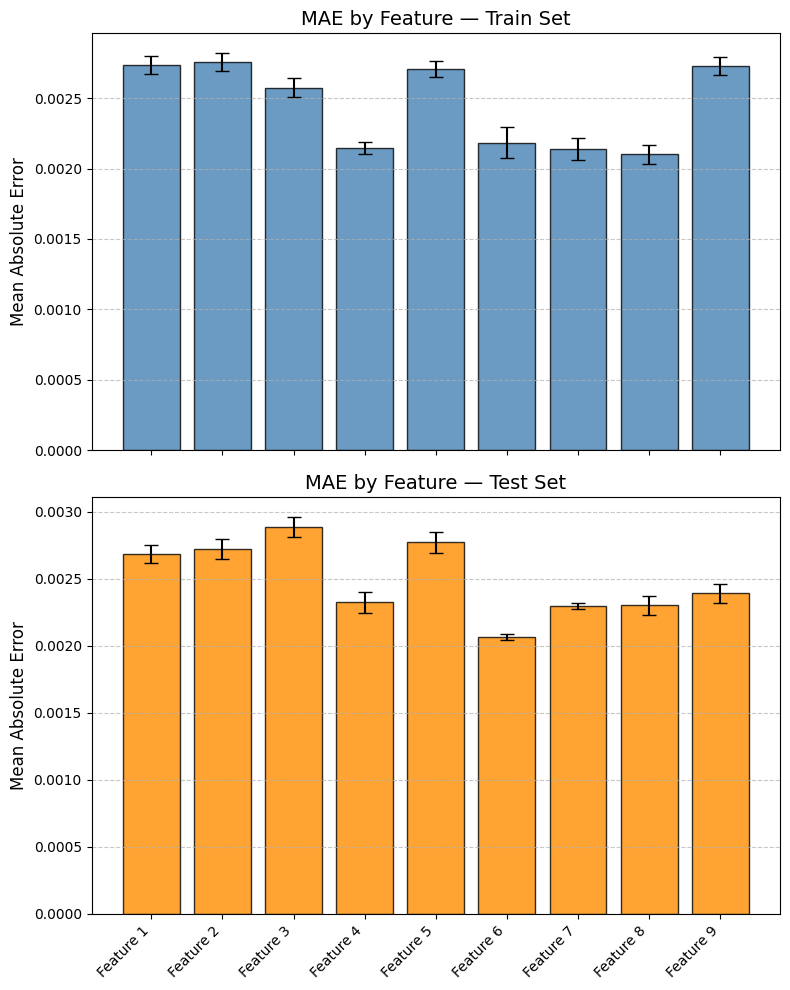

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Example data: mean MAE values + standard deviations for 9 features
# ------------------------------------------------------------------
feature_names = [f'Feature {i}' for i in range(1, 10)]

# Suppose these are the MAE + std for your train set
train_mae = [0.0027384153, 0.0027562218, 0.0025741328,
             0.0021473568, 0.0027048338, 0.0021849454,
             0.0021416380, 0.0021007970, 0.0027275957]
train_std = [0.0000639075, 0.0000636159, 0.0000677777,
             0.0000432931, 0.0000577084, 0.0001080440,
             0.0000787667, 0.0000673118, 0.0000644674]

# Suppose these are the MAE + std for your test set
test_mae = [0.0026866579, 0.0027251082, 0.0028898516,
            0.0023243685, 0.0027732478, 0.0020666579,
            0.0022982447, 0.0023040598, 0.0023938400]
test_std = [0.0000686603, 0.0000768149, 0.0000740040,
            0.0000789586, 0.0000789586, 0.0000188450,
            0.0000254077, 0.0000700040, 0.0000708607]

# -------------------------------
# Create the figure and subplots
# -------------------------------
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), sharex=True)

# -------------------------------
# Top plot: Train set MAE values
# -------------------------------
axes[0].bar(
    x=np.arange(len(feature_names)),
    height=train_mae,
    yerr=train_std,
    color='steelblue',
    edgecolor='black',
    capsize=5,
    alpha=0.8
)
axes[0].set_title("MAE by Feature — Train Set", fontsize=14)
axes[0].set_ylabel("Mean Absolute Error", fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# ------------------------------
# Bottom plot: Test set MAE values
# ------------------------------
axes[1].bar(
    x=np.arange(len(feature_names)),
    height=test_mae,
    yerr=test_std,
    color='darkorange',
    edgecolor='black',
    capsize=5,
    alpha=0.8
)
axes[1].set_title("MAE by Feature — Test Set", fontsize=14)
axes[1].set_ylabel("Mean Absolute Error", fontsize=12)
axes[1].set_xticks(np.arange(len(feature_names)))
axes[1].set_xticklabels(feature_names, rotation=45, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# --------------------------
# Tidy up and show the plot
# --------------------------
plt.tight_layout()
plt.show()
